In [3]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [4]:
dotenv_path = r"C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\notebooks\.env"
load_dotenv(dotenv_path=dotenv_path, override=True)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [5]:
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [6]:
query = """
SELECT
    invoice_no,
    customer_id,
    stock_code,
    quantity,
    unit_price,
    revenue,
    year,
    month,
    historical_return_rate,
    avg_product_revenue,
    avg_product_quantity,
    return_label
FROM ml.train_feature_return_risk
"""

df = pd.read_sql(query, engine)
df.head()

,invoice_no,customer_id,stock_code,quantity,unit_price,revenue,year,month,historical_return_rate,avg_product_revenue,avg_product_quantity,return_label
0,536370,12583,10002,48.0,0.85,40.80,2010,12,0.0,14.276531,16.795918,0
1,536382,16098,10002,12.0,0.85,10.20,2010,12,0.0,14.276531,16.795918,0
2,536863,17967,10002,1.0,0.85,0.85,2010,12,0.0,14.276531,16.795918,0
3,537047,13069,10002,1.0,0.85,0.85,2010,12,0.0,14.276531,16.795918,0
4,537227,17677,10002,24.0,0.85,20.40,2010,12,0.0,14.276531,16.795918,0


In [7]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(406829, 12)
invoice_no                 object
customer_id                object
stock_code                 object
quantity                  float64
unit_price                float64
revenue                   float64
year                        int64
month                       int64
historical_return_rate    float64
avg_product_revenue       float64
avg_product_quantity      float64
return_label                int64
dtype: object
invoice_no                0
customer_id               0
stock_code                0
quantity                  0
unit_price                0
revenue                   0
year                      0
month                     0
historical_return_rate    0
avg_product_revenue       0
avg_product_quantity      0
return_label              0
dtype: int64


In [8]:
df = df.copy()

df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")

df = df.dropna(subset=[
    "customer_id",
    "quantity",
    "unit_price",
    "revenue",
    "historical_return_rate",
    "avg_product_revenue",
    "avg_product_quantity",
    "return_label"
]).copy()

df.head()

,invoice_no,customer_id,stock_code,quantity,unit_price,revenue,year,month,historical_return_rate,avg_product_revenue,avg_product_quantity,return_label
0,536370,12583,10002,48.0,0.85,40.80,2010,12,0.0,14.276531,16.795918,0
1,536382,16098,10002,12.0,0.85,10.20,2010,12,0.0,14.276531,16.795918,0
2,536863,17967,10002,1.0,0.85,0.85,2010,12,0.0,14.276531,16.795918,0
3,537047,13069,10002,1.0,0.85,0.85,2010,12,0.0,14.276531,16.795918,0
4,537227,17677,10002,24.0,0.85,20.40,2010,12,0.0,14.276531,16.795918,0


In [9]:
df["return_label"].value_counts(dropna=False)

return_label
0    397924
1      8905
Name: count, dtype: int64

In [11]:
feature_cols = [
    "customer_id",
    "quantity",
    "unit_price",
    "revenue",
    "year",
    "month",
    "historical_return_rate",
    "avg_product_revenue",
    "avg_product_quantity"
]

X = df[feature_cols]
y = df["return_label"]

meta = df[["invoice_no", "customer_id", "stock_code", "return_label"]].copy()

In [12]:
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(325463, 9) (81366, 9)


In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
proba = model.predict_proba(X_test)[:, 1]
pred_label = (proba >= 0.5).astype(int)

In [15]:
auc = roc_auc_score(y_test, proba)
print("ROC AUC:", round(auc, 4))

print("\nClassification Report")
print(classification_report(y_test, pred_label))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_label))

ROC AUC: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79585
           1       1.00      1.00      1.00      1781

    accuracy                           1.00     81366
   macro avg       1.00      1.00      1.00     81366
weighted avg       1.00      1.00      1.00     81366


Confusion Matrix
[[79585     0]
 [    0  1781]]


In [16]:
result = meta_test.copy()
result["actual_return_label"] = y_test.values
result["predicted_return_probability"] = proba
result["predicted_return_label"] = pred_label
result["model_name"] = "logistic_regression"

result = result[
    [
        "invoice_no",
        "customer_id",
        "stock_code",
        "actual_return_label",
        "predicted_return_probability",
        "predicted_return_label",
        "model_name"
    ]
]

result.head()

,invoice_no,customer_id,stock_code,actual_return_label,predicted_return_probability,predicted_return_label,model_name
378876,565117,13089,84879,0,5.048661e-216,0,logistic_regression
401349,540554,18171,85180B,0,7.669642e-53,0,logistic_regression
352081,566933,18102,48187,0,1.151703e-249,0,logistic_regression
111193,577473,15919,22098,0,2.275110e-10,0,logistic_regression
341406,541292,15596,35809A,0,3.508278e-39,0,logistic_regression


In [17]:
result.sort_values("predicted_return_probability", ascending=False).head(20)

,invoice_no,customer_id,stock_code,actual_return_label,predicted_return_probability,predicted_return_label,model_name
8275,C537814,12712,20703,1,1.0,1,logistic_regression
367681,C561649,15746,84077,1,1.0,1,logistic_regression
301417,C572481,15632,23252,1,1.0,1,logistic_regression
67767,C564094,16550,21658,1,1.0,1,logistic_regression
68126,C568879,14680,21668,1,1.0,1,logistic_regression
154453,C548460,16801,22413,1,1.0,1,logistic_regression
68456,C565848,14606,21669,1,1.0,1,logistic_regression
274325,C577375,14441,23118,1,1.0,1,logistic_regression
43478,C538723,12434,21217,1,1.0,1,logistic_regression
5304,C564488,16859,18097C,1,1.0,1,logistic_regression


In [21]:
save_path = r"C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\prediction_return_risk.csv"

result.to_csv(save_path, index=False)
print("saved:", save_path)

saved: C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\prediction_return_risk.csv


In [19]:
result.to_sql(
    "prediction_return_risk",
    engine,
    schema="ml",
    if_exists="append",
    index=False
)

print("Inserted into ml.prediction_return_risk")

Inserted into ml.prediction_return_risk


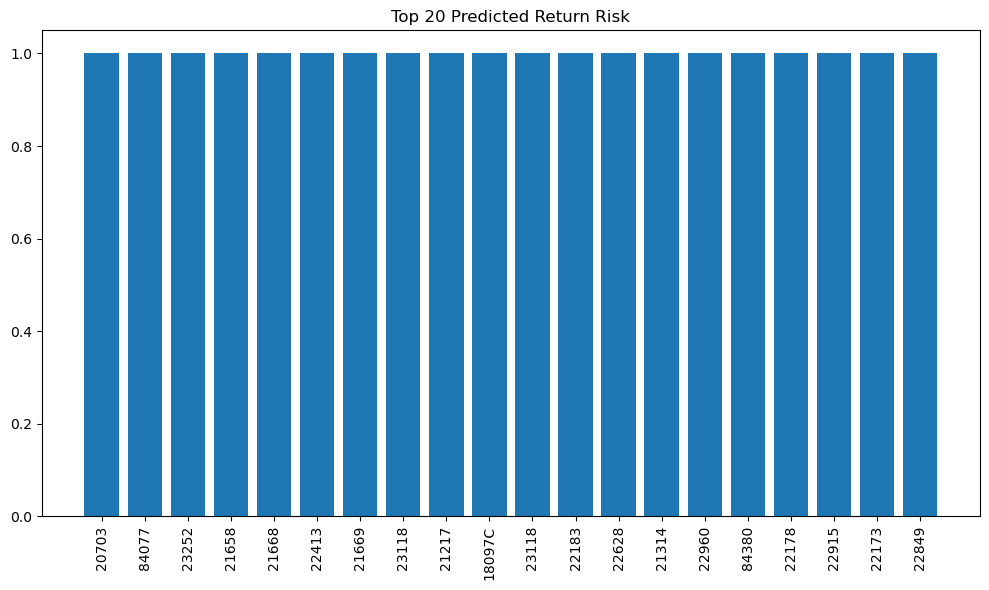

saved: C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\return_risk_top20.png


In [22]:
save_fig_path = r"C:\Users\htpar\Desktop\Github\End to End Retail Data Warehouse\Forcasting\result\return_risk_top20.png"

plt.figure(figsize=(10, 6))
plt.bar(range(len(top_risk)), top_risk["predicted_return_probability"])
plt.xticks(range(len(top_risk)), top_risk["stock_code"], rotation=90)
plt.title("Top 20 Predicted Return Risk")
plt.tight_layout()
plt.savefig(save_fig_path)
plt.show()

print("saved:", save_fig_path)